# 5. Modelado con scikit-learn

En esta sección se entrena un modelo de clasificación con scikit-learn para predecir `default`.
Se utiliza **RandomForestClassifier** y se ajustan hiperparámetros con **GridSearchCV**.

Se reportan métricas:
- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC
- Matriz de confusión

También se mide el tiempo de entrenamiento y predicción.

In [10]:
import warnings
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 5.1 Carga del dataset y separación de variables

Se carga el dataset limpio (`accepted_clean.csv`) y se separa:
- `X`: variables predictoras
- `y`: variable objetivo (`default`)

In [1]:
import pandas as pd

df = pd.read_csv("../data/accepted_clean.csv")

X = df.drop(columns=["default", "loan_status"])
y = df["default"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

C:\Users\PC\AppData\Local\Temp\ipykernel_18760\4255216637.py:3: DtypeWarning: Columns (0: desc, 1: verification_status_joint, 2: sec_app_earliest_cr_line, 3: hardship_type, 4: hardship_reason, 5: hardship_status, 6: hardship_start_date, 7: hardship_end_date, 8: payment_plan_start_date, 9: hardship_loan_status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/accepted_clean.csv")


Shape X: (1345310, 150)
Shape y: (1345310,)


## 5.2 División Train/Test

Se divide el dataset en entrenamiento y prueba (80/20) de forma estratificada
para preservar la proporción de clases.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1076248, 150) (1076248,)
Test : (269062, 150) (269062,)


## 5.3 Preprocesamiento (Pipeline)

Se construye un pipeline para:
- Imputación de nulos (numéricas: mediana, categóricas: moda)
- Escalado de numéricas
- OneHotEncoder para categóricas

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

C:\Users\PC\AppData\Local\Temp\ipykernel_18760\3430104298.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


## 5.4 Validación cruzada y selección de hiperparámetros

Para evitar sobreajuste y obtener una estimación robusta del rendimiento del modelo,
se utilizó validación cruzada estratificada dentro de `GridSearchCV`.

La selección de hiperparámetros se realizó exclusivamente sobre el conjunto de entrenamiento,
evitando utilizar el conjunto de prueba durante el proceso de optimización.

Es importante destacar que la validación cruzada no construye un modelo final, sino que
evalúa la capacidad de generalización del algoritmo bajo múltiples particiones de los datos.
El modelo final es reentrenado automáticamente por `GridSearchCV` utilizando los mejores
hiperparámetros encontrados.

### 5.4.1 Entrenamiento con RandomForest + GridSearchCV

Se entrena un RandomForestClassifier y se ajustan hiperparámetros con GridSearchCV:

- n_estimators: [10, 50, 100]
- max_depth: [5, 10, 15]

Se mide el tiempo total de entrenamiento.

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Modelo base
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Pipeline completo (preprocesamiento + modelo)
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", rf)
])

#  Grid reducido (4 combinaciones en vez de 9)
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, 15]
}

#  n_jobs=1 para evitar problemas de multiprocessing en Windows
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=1,
    verbose=0
)

t0 = time.time()
grid.fit(X_train, y_train)
train_time = time.time() - t0

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Tiempo entrenamiento (GridSearch): {train_time:.2f} s")

Mejores hiperparámetros: {'model__max_depth': 15, 'model__n_estimators': 100}
Tiempo entrenamiento (GridSearch): 809.76 s


## 5.5 Evaluación del modelo en test (métricas)

Se evalúa el mejor modelo encontrado por GridSearchCV sobre el conjunto de prueba (test).

Métricas reportadas:
- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

# Predicciones
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

# Métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== MÉTRICAS (RandomForest - sklearn) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

=== MÉTRICAS (RandomForest - sklearn) ===
Accuracy : 0.9204
Precision: 0.7818
Recall   : 0.8337
F1-score : 0.8070
ROC AUC  : 0.9511


## 5.6 Matriz de confusión

La matriz de confusión permite observar:
- Verdaderos positivos (TP)
- Verdaderos negativos (TN)
- Falsos positivos (FP)
- Falsos negativos (FN)

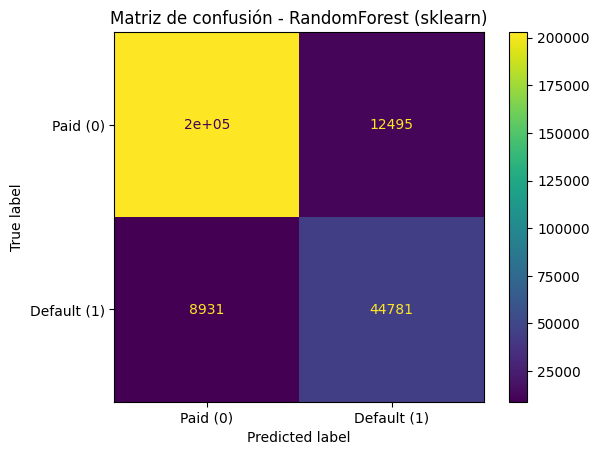

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Paid (0)", "Default (1)"]
)

disp.plot()
plt.title("Matriz de confusión - RandomForest (sklearn)")
plt.show()

## 5.7 Curva ROC

Se grafica la curva ROC para evaluar la capacidad discriminativa del modelo.
El AUC (área bajo la curva) se reporta como medida global de desempeño.

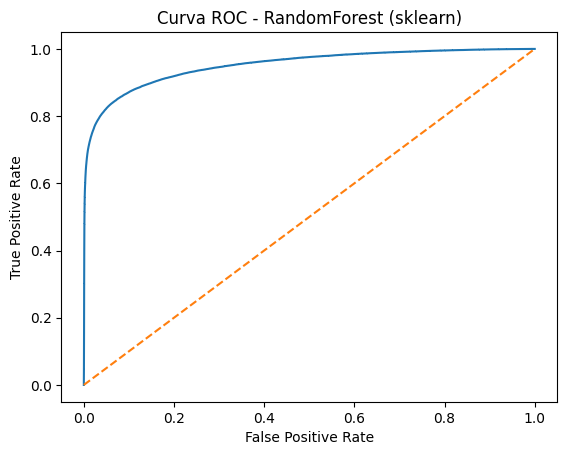

In [8]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - RandomForest (sklearn)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## 5.8 Tabla resumen de resultados (sklearn)

Se almacena un resumen con las métricas y tiempos obtenidos
para comparar posteriormente con PySpark.

In [9]:
import pandas as pd

results_sklearn = pd.DataFrame([{
    "model": "RandomForest (sklearn)",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "roc_auc": auc,
    "train_time_s": train_time,
    "best_params": str(grid.best_params_)
}])

results_sklearn

,model,accuracy,precision,recall,f1,roc_auc,train_time_s,best_params
0,RandomForest (sklearn),0.920368,0.781846,0.833724,0.806952,0.95111,847.036006,"{'model__max_depth': 15, 'model__n_estimators'..."


In [17]:
import os
import joblib

# Crear carpeta models si no existe
os.makedirs("models", exist_ok=True)

# Guardar el mejor modelo del GridSearch
joblib.dump(grid.best_estimator_, "models/rf_model.pkl")

print("Modelo guardado correctamente en models/rf_model.pkl")

Modelo guardado correctamente en models/rf_model.pkl
